# Double ML causal inference

### Импорты

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

import doubleml as dml

from sklearn.base import ClassifierMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

import xgboost as xgb
import optuna

from optuna.integration import OptunaSearchCV
from optuna.distributions import IntDistribution, FloatDistribution

from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

import warnings

alpha = 0.1
RANDOM_STATE = 123

sns.set_style("whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)

### Данные

In [3]:
df = pd.read_csv("../data/final_dataset.csv")
df_men = df[df["sex"] == 1]
df_women = df[df["sex"] == 2]

In [4]:
df_men

,heart,lungs,liver,kidneys,stomach,spine,diabetes,hypertension,joints,ENT_organs,...,invalid,mar_st,visit_doctor,work,alcohol,smoking,phys_active,is_health_good,is_health_very_good,diploma
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0
8,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
16,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4586,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
4587,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
4589,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [5]:
df_women

,heart,lungs,liver,kidneys,stomach,spine,diabetes,hypertension,joints,ENT_organs,...,invalid,mar_st,visit_doctor,work,alcohol,smoking,phys_active,is_health_good,is_health_very_good,diploma
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4591,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
treatment = "diploma"
controls = ["age", "type_area", "invalid"]

### Вспомогательные функции и сетки гиперпараметров

In [ ]:
rf_distributions = {
    "n_estimators": IntDistribution(100, 500, step=50),
    "max_depth": IntDistribution(3, 12),
    "min_samples_leaf": IntDistribution(2, 20),
}

xgb_distributions = {
    "n_estimators": IntDistribution(100, 500, step=50),
    "max_depth": IntDistribution(3, 8),
    "learning_rate": FloatDistribution(0.01, 0.2, log=True),
}


class _ClassifierOptunaSearchCV(ClassifierMixin, OptunaSearchCV):
    pass


def _make_learner(model):
    if model == "LDA":
        return LinearDiscriminantAnalysis()
    if model == "RF":
        base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
        return _ClassifierOptunaSearchCV(
            base,
            param_distributions=rf_distributions,
            n_trials=20,
            cv=3,
            random_state=RANDOM_STATE,
            verbose=0,
        )
    if model == "XGB":
        base = xgb.XGBClassifier(
            random_state=RANDOM_STATE,
            verbosity=0,
            eval_metric="logloss",
        )
        return _ClassifierOptunaSearchCV(
            base,
            param_distributions=xgb_distributions,
            n_trials=20,
            cv=3,
            random_state=RANDOM_STATE,
            verbose=0,
        )


def fit_irm(dml_data, model, score):
    score_internal = "ATTE" if score == "ATET" else "ATE"

    irm = dml.DoubleMLIRM(
        dml_data,
        ml_g=_make_learner(model),
        ml_m=_make_learner(model),
        ps_processor_config=dml.utils.PSProcessorConfig(clipping_threshold=0.03),
        n_folds=3,
        score=score_internal,
    )
    irm.fit(n_jobs_cv=-1)
    return irm


def print_all_models(dml_data, label=""):
    for model in ["LDA", "RF", "XGB"]:
        for score in ["ATE", "ATET"]:
            irm = fit_irm(dml_data, model, score)
            header = f"{label} | {model} | {score}".strip(" |")
            print(f"--- {header} ---")
            print(irm.summary)
            print(irm.confint(level=1 - alpha))
            print()

### Женщины и гипертония

In [8]:
outcome = "hypertension"

In [9]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [10]:
print_all_models(dml_data_women, label="Women + hypertension")

--- Women + hypertension | LDA | ATE ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma -0.038668  0.015616 -2.476195  0.013279 -0.069275 -0.008062
            5.0 %    95.0 %
diploma -0.064355 -0.012982

--- Women + hypertension | LDA | ATET ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma -0.029787  0.014674 -2.029924  0.042364 -0.058547 -0.001027
            5.0 %   95.0 %
diploma -0.053923 -0.00565

--- Women + hypertension | RF | ATE ---
             coef   std err         t     P>|t|     2.5 %   97.5 %
diploma -0.040716  0.015463 -2.633163  0.008459 -0.071023 -0.01041
            5.0 %    95.0 %
diploma -0.066151 -0.015282

--- Women + hypertension | RF | ATET ---
             coef   std err         t     P>|t|    2.5 %    97.5 %
diploma -0.027216  0.014773 -1.842296  0.065432 -0.05617  0.001738
            5.0 %    95.0 %
diploma -0.051515 -0.002917

--- Women + hypertension | XGB | ATE ---
             coef   std err  

### Женщины и заболевания глаз

In [11]:
outcome = "eyes"

In [12]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [13]:
print_all_models(dml_data_women, label="Women + eyes")

--- Women + eyes | LDA | ATE ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.015613  0.012974  1.203361  0.228837 -0.009816  0.041042
            5.0 %    95.0 %
diploma -0.005728  0.036954

--- Women + eyes | LDA | ATET ---
            coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.01754  0.013101  1.338842  0.180622 -0.008137  0.043218
            5.0 %   95.0 %
diploma -0.004009  0.03909

--- Women + eyes | RF | ATE ---
            coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.01812  0.012955  1.398721  0.161897 -0.007271  0.043511
            5.0 %    95.0 %
diploma -0.003189  0.039429

--- Women + eyes | RF | ATET ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.021112  0.012833  1.645197  0.099929 -0.004039  0.046264
            5.0 %   95.0 %
diploma  0.000004  0.04222

--- Women + eyes | XGB | ATE ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
dip

### Женщины и аллергия

In [14]:
outcome = "allergy"

In [15]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [16]:
print_all_models(dml_data_women, label="Women + allergy")

--- Women + allergy | LDA | ATE ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.009047  0.011101  0.814974  0.415087 -0.012711  0.030806
            5.0 %    95.0 %
diploma -0.009213  0.027308

--- Women + allergy | LDA | ATET ---
             coef   std err         t   P>|t|     2.5 %    97.5 %
diploma  0.010441  0.011111  0.939644  0.3474 -0.011337  0.032219
            5.0 %    95.0 %
diploma -0.007836  0.028717

--- Women + allergy | RF | ATE ---
             coef  std err         t   P>|t|     2.5 %   97.5 %
diploma  0.011582  0.01153  1.004578  0.3151 -0.011015  0.03418
            5.0 %    95.0 %
diploma -0.007382  0.030547

--- Women + allergy | RF | ATET ---
             coef   std err         t     P>|t|     2.5 %   97.5 %
diploma  0.004943  0.011616  0.425488  0.670481 -0.017825  0.02771
            5.0 %   95.0 %
diploma -0.014165  0.02405

--- Women + allergy | XGB | ATE ---
             coef   std err         t     P>|t|     2.5 %    97.

### Мужчины и оценка состояния здоровья

In [17]:
outcome = "is_health_good"

In [18]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [19]:
print_all_models(dml_data_men, label="Men + is_health_good")

--- Men + is_health_good | LDA | ATE ---
            coef  std err         t     P>|t|     2.5 %    97.5 %
diploma  0.02204  0.02443  0.902147  0.366979 -0.025843  0.069923
            5.0 %    95.0 %
diploma -0.018145  0.062224

--- Men + is_health_good | LDA | ATET ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.012682  0.023896  0.530723  0.595611 -0.034153  0.059517
            5.0 %    95.0 %
diploma -0.026623  0.051987

--- Men + is_health_good | RF | ATE ---
            coef   std err         t    P>|t|     2.5 %    97.5 %
diploma  0.00706  0.025287  0.279215  0.78008 -0.042501  0.056622
            5.0 %    95.0 %
diploma -0.034533  0.048654

--- Men + is_health_good | RF | ATET ---
             coef   std err         t     P>|t|   2.5 %    97.5 %
diploma  0.007724  0.024145  0.319888  0.749053 -0.0396  0.055048
            5.0 %   95.0 %
diploma -0.031992  0.04744

--- Men + is_health_good | XGB | ATE ---
            coef   std err         t 

### Другие интересные наблюдения

In [ ]:
diseases = [
    "heart",
    "lungs",
    "liver",
    "kidneys",
    "stomach",
    "spine",
    "diabetes",
    "hypertension",
    "joints",
    "ENT_organs",
    "neurology",
    "eyes",
    "allergy",
    "veins",
    "is_health_good",
]

results = []

for outcome in tqdm(diseases):
    dml_data_w = dml.DoubleMLData(
        df_women, y_col=outcome, d_cols=treatment, x_cols=controls
    )
    dml_data_m = dml.DoubleMLData(
        df_men, y_col=outcome, d_cols=treatment, x_cols=controls
    )

    for gender, dml_data in [("Women", dml_data_w), ("Men", dml_data_m)]:
        for score in ["ATE", "ATET"]:
            irm = fit_irm(dml_data, "RF", score)
            p_val = irm.pval.item()
            ci = irm.confint(level=1 - alpha)
            results.append({
                "outcome": outcome,
                "gender": gender,
                "model": "RF",
                "score": score,
                "coef": irm.coef.item(),
                "se": irm.se.item(),
                "p_val": p_val,
                "ci_low": ci.iloc[0, 0],
                "ci_high": ci.iloc[0, 1],
                "significant": p_val <= alpha,
            })

results_df = pd.DataFrame(results)

results_df["p_val_bonf"] = multipletests(
    results_df["p_val"], alpha=alpha, method="bonferroni"
)[1]
results_df["significant_bonf"] = results_df["p_val_bonf"] <= alpha

  0%|          | 0/15 [00:00<?, ?it/s]

C:\Users\alexv\AppData\Local\Temp\ipykernel_24760\2941446333.py:23: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return _ClassifierOptunaSearchCV(
c:\Users\alexv\Econometrics-project\.venv\Lib\site-packages\sklearn\base.py:129: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  new_object = klass(**new_object_params)
c:\Users\alexv\Econometrics-project\.venv\Lib\site-packages\sklearn\base.py:129: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  new_object = klass(**new_object_params)
c:\Users\alexv\Econometrics-project\.venv\Lib\site-packages\sklearn\base.py:129: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  new_object = klass(**new_object_params)
c:\Users\alexv\Econometrics-project\.venv\Lib\site-pack

Collected 60 estimates (15 outcomes x 2 genders x 2 scores, RF only).


In [ ]:
sig = results_df[results_df["significant_bonf"]].copy()

for (gender, outcome), grp in sig.groupby(["gender", "outcome"], sort=False):
    print(f"{gender} - {outcome}:")
    for _, r in grp.iterrows():
        print(
            f"  {r['model']:3s} | {r['score']:4s} | "
            f"coef={round(r['coef'], 4)}  "
            f"p_raw={round(r['p_val'], 4)}  "
            f"p_bonf={round(r['p_val_bonf'], 4)}  "
            f"CI=[{round(r['ci_low'], 4)}, {round(r['ci_high'], 4)}]"
        )
    print()

Total Bonferroni-significant estimates (p_bonf <= 0.1): 4

Women - lungs:
  RF  | ATE  | coef=-0.0389  p_raw=0.0  p_bonf=0.0021  CI=[-0.0544, -0.0235]
  RF  | ATET | coef=-0.0416  p_raw=0.0  p_bonf=0.0027  CI=[-0.0584, -0.0248]

Women - is_health_good:
  RF  | ATE  | coef=0.071  p_raw=0.0002  p_bonf=0.0097  CI=[0.04, 0.1019]
  RF  | ATET | coef=0.075  p_raw=0.0002  p_bonf=0.0101  CI=[0.0422, 0.1077]



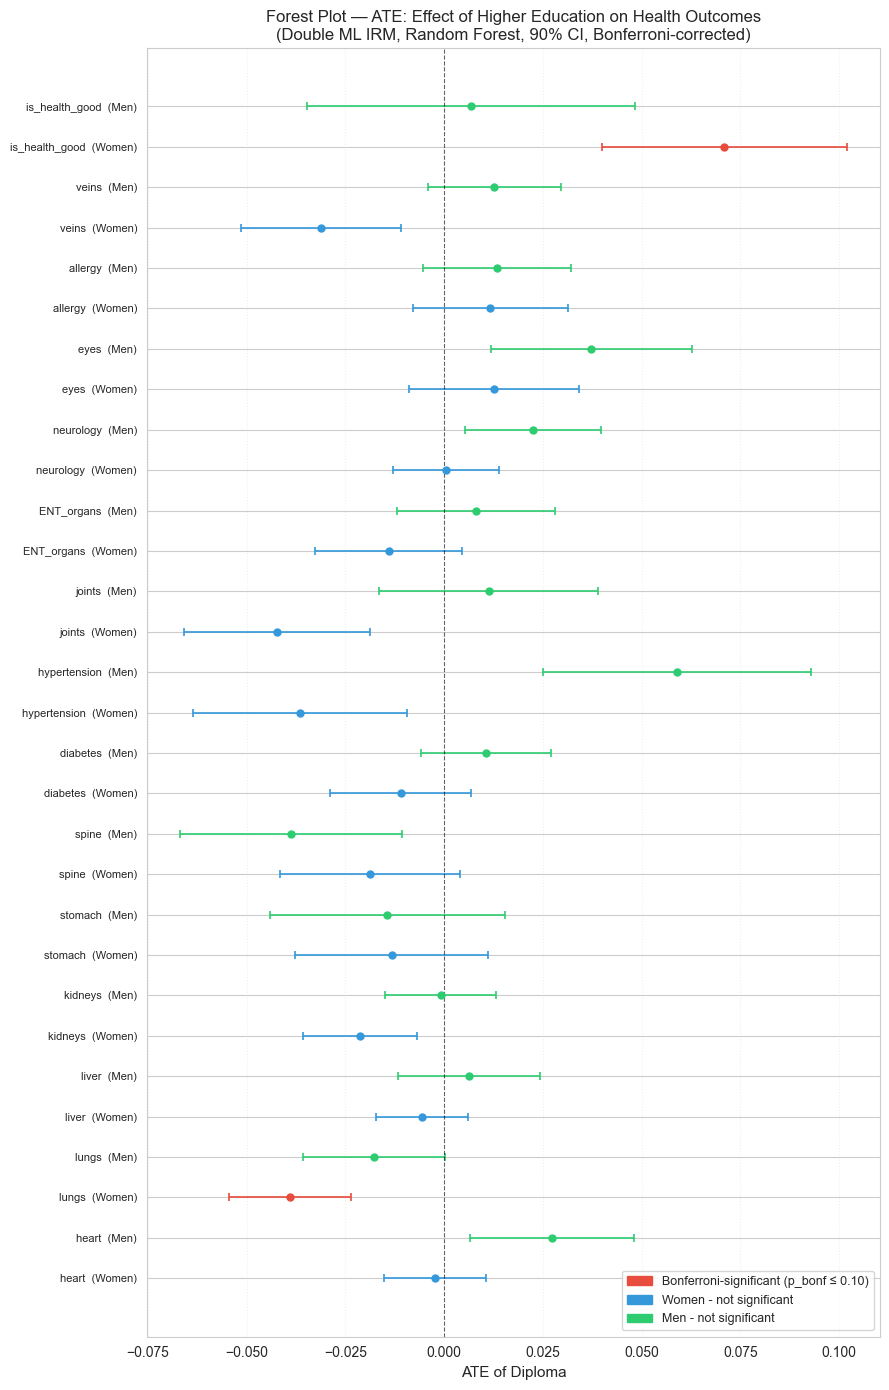

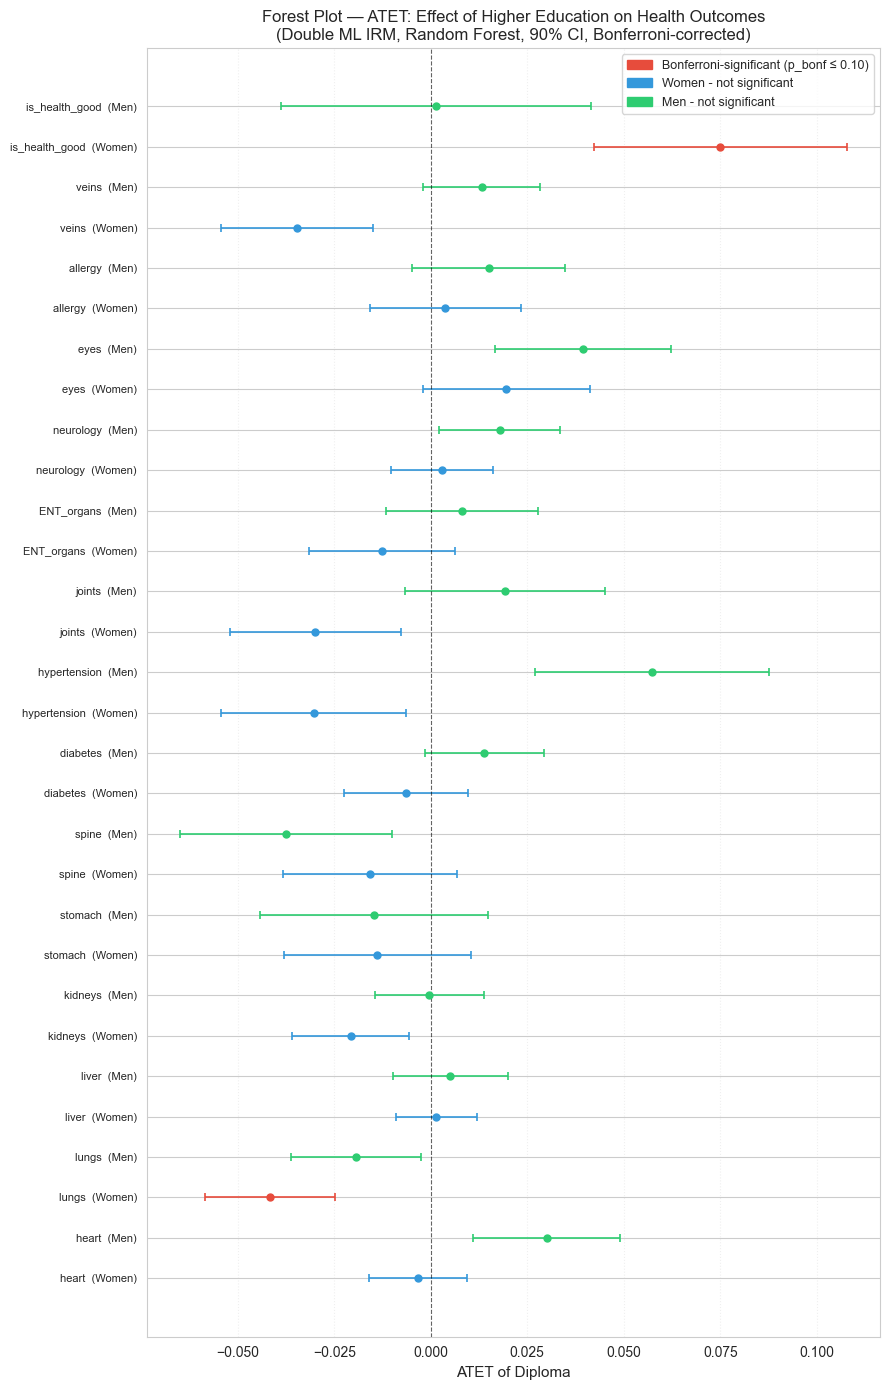

In [ ]:
for sc in ["ATE", "ATET"]:
    fig, ax = plt.subplots(figsize=(9, 14))

    sub = results_df[
        (results_df["model"] == "RF") & (results_df["score"] == sc)
    ].reset_index(drop=True)

    for i, r in sub.iterrows():
        if r["significant_bonf"]:
            color = "#e74c3c"
        elif r["gender"] == "Women":
            color = "#3498db"
        else:
            color = "#2ecc71"

        ax.errorbar(
            r["coef"],
            i,
            xerr=[[r["coef"] - r["ci_low"]], [r["ci_high"] - r["coef"]]],
            fmt="o",
            color=color,
            capsize=3,
            capthick=1.2,
            linewidth=1.2,
            markersize=5,
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_yticks(np.arange(len(sub)))
    ax.set_yticklabels(
        [f"{r['outcome']}  ({r['gender']})" for _, r in sub.iterrows()],
        fontsize=8,
    )
    ax.set_xlabel(f"{sc} of Diploma", fontsize=11)
    ax.grid(axis="x", alpha=0.3, linestyle=":")

    sig_patch = mpatches.Patch(
        color="#e74c3c", label="Bonferroni-significant (p_bonf ≤ 0.10)"
    )
    w_patch = mpatches.Patch(color="#3498db", label="Women - not significant")
    m_patch = mpatches.Patch(color="#2ecc71", label="Men - not significant")
    ax.legend(handles=[sig_patch, w_patch, m_patch], fontsize=9, loc="best")

    ax.set_title(
        f"Forest Plot - {sc}: Effect of Higher Education on Health Outcomes\n"
        f"(Double ML IRM, Random Forest, 90% CI, Bonferroni-corrected)",
        fontsize=12,
    )

    plt.tight_layout()
    plt.savefig(f"../assets/dml_forest_plot_{sc.lower()}.png")
    plt.show()

C:\Users\alexv\AppData\Local\Temp\ipykernel_24760\2941446333.py:23: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return _ClassifierOptunaSearchCV(
c:\Users\alexv\Econometrics-project\.venv\Lib\site-packages\sklearn\base.py:129: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  new_object = klass(**new_object_params)
c:\Users\alexv\Econometrics-project\.venv\Lib\site-packages\sklearn\base.py:129: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  new_object = klass(**new_object_params)
c:\Users\alexv\Econometrics-project\.venv\Lib\site-packages\sklearn\base.py:129: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  new_object = klass(**new_object_params)
C:\Users\alexv\AppData\Local\Temp\ipykernel_24760\29414

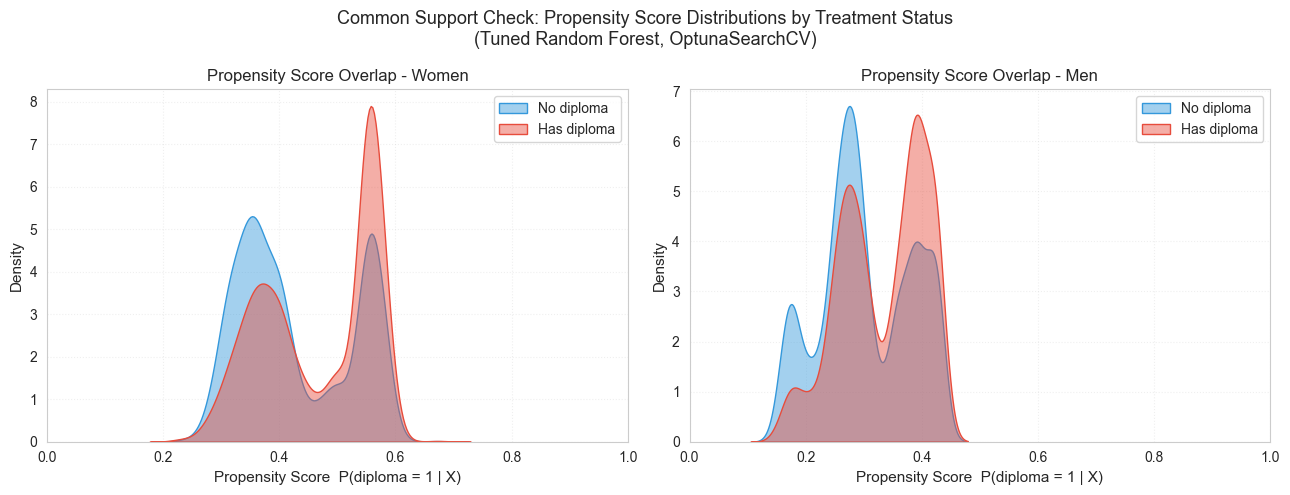

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (df_g, gender) in zip(axes, [(df_women, "Women"), (df_men, "Men")]):
    X = df_g[controls].values
    d = df_g[treatment].values.astype(int)
    clf = _make_learner("RF")
    ps = cross_val_predict(clf, X, d, cv=3, method="predict_proba")[:, 1]

    sns.kdeplot(
        ps[d == 0],
        ax=ax,
        label="No diploma",
        fill=True,
        alpha=0.45,
        color="#3498db",
        bw_adjust=0.8,
    )
    sns.kdeplot(
        ps[d == 1],
        ax=ax,
        label="Has diploma",
        fill=True,
        alpha=0.45,
        color="#e74c3c",
        bw_adjust=0.8,
    )

    ax.set_xlim(0, 1)
    ax.set_xlabel("Propensity Score  P(diploma = 1 | X)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"Propensity Score Overlap - {gender}", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle=":")

plt.suptitle(
    "Common Support Check: Propensity Score Distributions by Treatment Status\n"
    "(Tuned Random Forest, OptunaSearchCV)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig("..assets/dml_propensity_score.png")


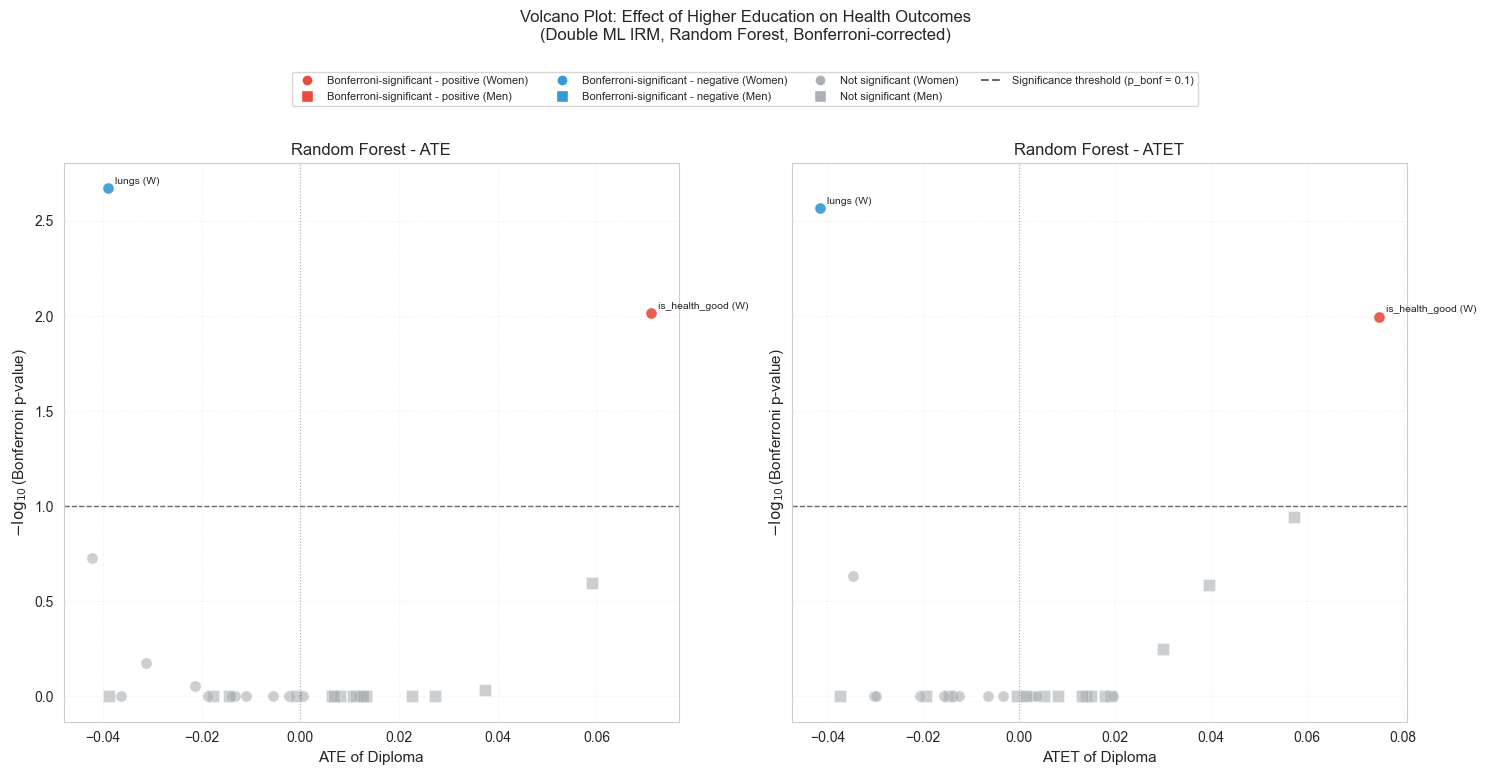

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

for ax, sc in zip(axes, ["ATE", "ATET"]):
    sub = results_df[(results_df["model"] == "RF") & (results_df["score"] == sc)]

    for _, r in sub.iterrows():
        coef = r["coef"]
        neg_log_p = -np.log10(r["p_val_bonf"])
        marker = "o" if r["gender"] == "Women" else "s"

        if not r["significant_bonf"]:
            color, zorder, alpha_pt = "#aab0b5", 1, 0.6
        elif coef > 0:
            color, zorder, alpha_pt = "#e74c3c", 3, 0.9
        else:
            color, zorder, alpha_pt = "#3498db", 3, 0.9

        ax.scatter(
            coef,
            neg_log_p,
            color=color,
            marker=marker,
            s=65,
            zorder=zorder,
            alpha=alpha_pt,
            edgecolors="white",
            linewidths=0.4,
        )

        if r["significant_bonf"]:
            ax.annotate(
                f"{r['outcome']} ({r['gender'][0]})",
                (coef, neg_log_p),
                fontsize=7.5,
                xytext=(5, 3),
                textcoords="offset points",
            )

    ax.axhline(
        -np.log10(alpha),
        color="dimgray",
        linestyle="--",
        linewidth=1,
    )
    ax.axvline(0, color="dimgray", linestyle=":", linewidth=0.8, alpha=0.5)

    ax.set_xlabel(f"{sc} of Diploma", fontsize=11)
    ax.set_ylabel(r"$-\log_{10}$(Bonferroni p-value)", fontsize=11)
    ax.set_title(f"Random Forest - {sc}", fontsize=12)
    ax.grid(alpha=0.3, linestyle=":")

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#e74c3c",
        markersize=8,
        label="Bonferroni-significant - positive (Women)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#e74c3c",
        markersize=8,
        label="Bonferroni-significant - positive (Men)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#3498db",
        markersize=8,
        label="Bonferroni-significant - negative (Women)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#3498db",
        markersize=8,
        label="Bonferroni-significant - negative (Men)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#aab0b5",
        markersize=8,
        label="Not significant (Women)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#aab0b5",
        markersize=8,
        label="Not significant (Men)",
    ),
    Line2D(
        [0],
        [0],
        linestyle="--",
        color="dimgray",
        label=f"Significance threshold (p_bonf = {alpha})",
    ),
]
fig.legend(
    handles=legend_handles,
    fontsize=8,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Volcano Plot: Effect of Higher Education on Health Outcomes\n"
    "(Double ML IRM, Random Forest, Bonferroni-corrected)",
    fontsize=12,
    y=1.10,
)

plt.tight_layout()
plt.savefig("../assets/dml_volcano_plot.png")


### Выводы